In [1]:
!pip install shap

Data Loaded Successfully!
Shape of Dataset: (10297, 21)

--- Confusion Matrix ---
[[1774   64]
 [ 101  121]]

--- Classification Report (F1-Score) ---
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1838
           1       0.65      0.55      0.59       222

    accuracy                           0.92      2060
   macro avg       0.80      0.76      0.78      2060
weighted avg       0.91      0.92      0.92      2060



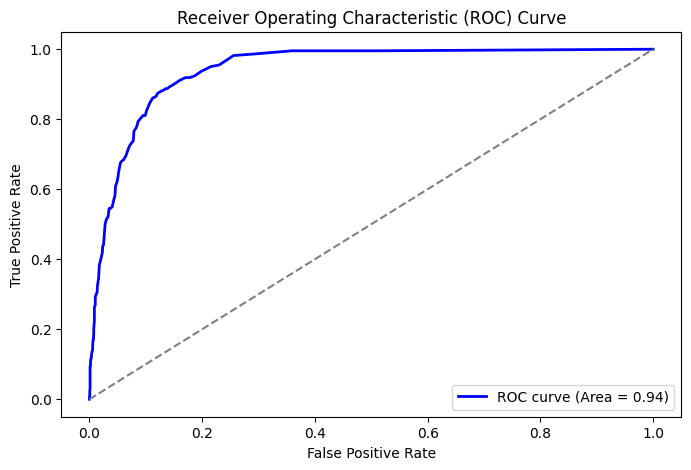


--- SHAP Summary for Model Interpretability ---


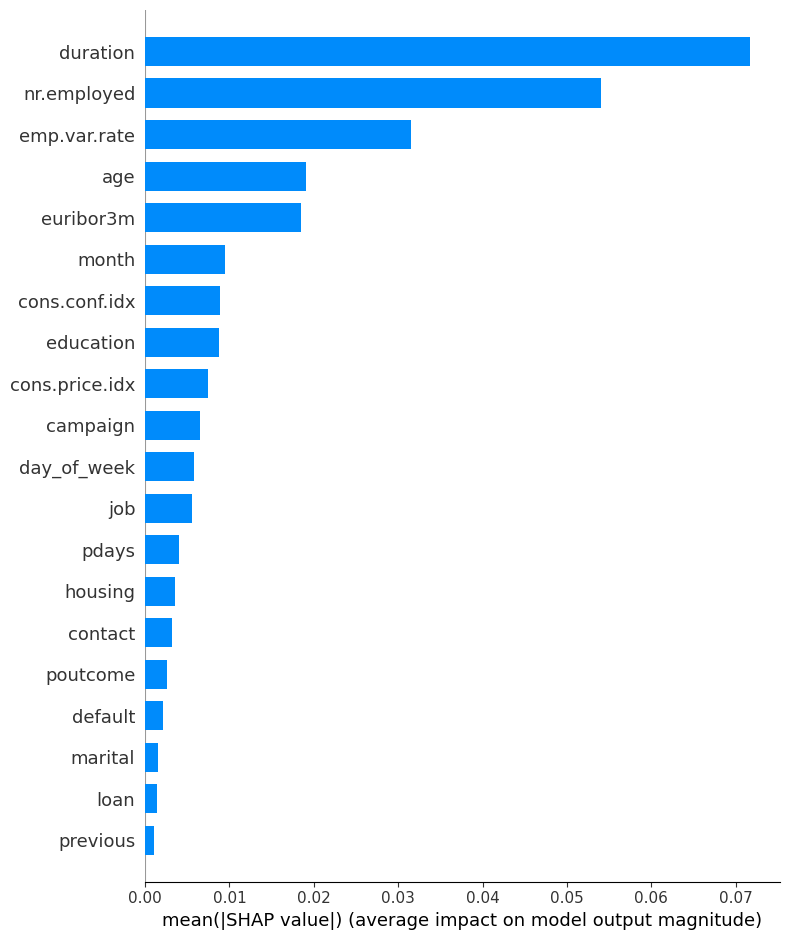

In [3]:
# --- ADVANCED TASK 1: TERM DEPOSIT SUBSCRIPTION PREDICTION ---
# Objective: Predict if a customer will subscribe to a term deposit.

# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import shap

# 2. LOAD DATASET
# Bank Marketing Dataset ko direct load kar rahe hain
url = "https://raw.githubusercontent.com/insaid2018/Term-2/master/Data/bank.csv"
df = pd.read_csv(url)
print("Data Loaded Successfully!")
print(f"Shape of Dataset: {df.shape}\n")

# 3. ENCODE CATEGORICAL FEATURES
# Text data (jaise 'job', 'marital') ko numbers mein convert kar rahe hain
le = LabelEncoder()
text_columns = df.select_dtypes(include=['object']).columns

for col in text_columns:
    df[col] = le.fit_transform(df[col])

# 4. SPLIT DATA INTO TRAINING & TESTING
# 'y' target hai (Yes/No for subscription)
X = df.drop(columns=['y'])
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. TRAIN CLASSIFICATION MODEL
# Instructions ke mutabiq Random Forest use kar rahe hain
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 6. EVALUATE MODEL (F1-Score, Confusion Matrix, ROC Curve)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1] # ROC Curve ke liye probabilities chahiye

print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

print("\n--- Classification Report (F1-Score) ---")
print(classification_report(y_test, y_pred))

# ROC Curve Plot
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (Area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# 7. EXPLAINABLE AI (SHAP)
# Kam az kam 5 predictions ko explain karna hai
print("\n--- SHAP Summary for Model Interpretability ---")
explainer = shap.TreeExplainer(model)
X_sample = X_test.iloc[:5] # 5 predictions ka sample le rahe hain

# SHAP values calculate karein
shap_values = explainer.shap_values(X_sample)

# SHAP library ke naye aur purane versions ke liye fix:
if isinstance(shap_values, list):
    # Agar purana version hai to list ka second item (Class 'Yes') lein
    shap_values_to_plot = shap_values[1]
else:
    # Agar naya version hai to 3D array se Class 'Yes' extract karein
    shap_values_to_plot = shap_values[:, :, 1]

# SHAP values ka bar chart plot karein
shap.summary_plot(shap_values_to_plot, X_sample, plot_type="bar")